In [1]:
pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=7a48e58e5987a78070cbb3bb81d9e4014f25d889f83587800617f1352743c252
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [3]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("--- 1단계: 데이터 불러오기 및 전처리 시작 ---")

# --- 데이터 불러오기 ---
file_path = '/content/Total_Data_v2.CSV'
df = pd.read_csv(file_path, encoding='cp949')
print(f"'{file_path}' 파일 불러오기 성공")

# --- 날짜 컬럼 변환 ---
df['개설일'] = pd.to_datetime(df['개설일'], errors='coerce')
df['폐업일'] = pd.to_datetime(df['폐업일'], errors='coerce')
df['기준년월'] = pd.to_datetime(df['기준년월'], errors='coerce')
df['기준년월'] = df['기준년월'].dt.to_period('M').dt.to_timestamp()

# --- 폐업일이 없는 경우 기준년월로 대체 ---
df['폐업일'] = df['폐업일'].fillna(df['기준년월'])

# --- 운영개월 계산 ---
df['운영개월'] = (
    (df['폐업일'].dt.year - df['개설일'].dt.year) * 12 +
    (df['폐업일'].dt.month - df['개설일'].dt.month)
).clip(lower=0)

# --- event 정의 ---
df['event'] = np.where(df['폐업일'].notna() & (df['폐업일'] < df['기준년월']), 1, 0)

# --- 텍스트 컬럼 제거 ---
drop_cols = ['가맹점명', '가맹점주소']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

print(f"데이터셋 크기: {df.shape}")
print("\n--- 2단계: 변수 선택 및 정제 ---")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['event', '운영개월']]

# 1️⃣ 분산이 낮은 컬럼 제거
low_var_cols = [col for col in numeric_cols if df[col].var() < 1e-5]
if low_var_cols:
    print("분산이 낮은 컬럼 제거:", low_var_cols)
    df = df.drop(columns=low_var_cols)
    numeric_cols = [col for col in numeric_cols if col not in low_var_cols]
# 3️⃣ 결측/무한대 처리
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['운영개월', 'event'] + numeric_cols)
# 2️⃣ VIF로 다중공선성 제거
def calculate_vif(df, cols):
    vif_data = pd.DataFrame()
    vif_data["feature"] = cols
    vif_data["VIF"] = [variance_inflation_factor(df[cols].values, i)
                       for i in range(len(cols))]
    return vif_data

vif_df = calculate_vif(df, numeric_cols)
high_vif_cols = vif_df[vif_df["VIF"] > 10]["feature"].tolist()
if high_vif_cols:
    print("다중공선성 높은 컬럼 제거:", high_vif_cols)
    df = df.drop(columns=high_vif_cols)
    numeric_cols = [col for col in numeric_cols if col not in high_vif_cols]


print("\n--- 3단계: Cox 비례위험모형 적합 ---")
cph = CoxPHFitter()
cph.fit(df[['운영개월', 'event'] + numeric_cols],
        duration_col='운영개월', event_col='event')
cph.print_summary()

# 4️⃣ 성능지표
c_index = concordance_index(df['운영개월'], -cph.predict_partial_hazard(df), df['event'])
print(f"\n모형 Concordance Index: {c_index:.4f}")
print("\n--- 분석 완료 ---")


--- 1단계: 데이터 불러오기 및 전처리 시작 ---
'/content/Total_Data_v2.CSV' 파일 불러오기 성공
데이터셋 크기: (50907, 53)

--- 2단계: 변수 선택 및 정제 ---
분산이 낮은 컬럼 제거: ['3개월 연속 감소 여부']
다중공선성 높은 컬럼 제거: ['동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율_x', '동일 업종 내 해지 가맹점 비중_x', '남성 20대이하 고객 비중', '남성 30대 고객 비중', '남성 40대 고객 비중', '남성 50대 고객 비중', '남성 60대이상 고객 비중', '여성 20대이하 고객 비중', '여성 30대 고객 비중', '여성 40대 고객 비중', '여성 50대 고객 비중', '여성 60대이상 고객 비중', '재방문 고객 비중_x', '신규 고객 비중', '거주 이용 고객 비율', '직장 이용 고객 비율', '유동인구 이용 고객 비율', '동일 상권 내 매출 순위 비율_y', '동일 업종 내 해지 가맹점 비중_y', '고객분포_다양성지수']

--- 3단계: Cox 비례위험모형 적합 ---


<lifelines.CoxPHFitter: fitted with 27000 total observations, 26157 right-censored observations>
             duration col = '운영개월'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 27000
number of events observed = 843
   partial log-likelihood = -8425.77
         time fit was run = 2025-10-21 12:05:10 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
Unnamed: 0           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
배달매출금액 비율            0.00      1.00      0.00            0.00            0.00                1.00                1.00
동일 업종 매출금액 비율_x      0.00      1.00      0.00            0.00            0.00                1.00                1.00
동일 업종 매출건수 비율        0.00      1.00      0.00            0.00            0.00                1.00                1.00
동일 상권 내 해지 가맹점 비중   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
전월대비 매출금액 감소율(%)     0.00      1.00      0.00           -0.00            0.00                1.00                1.00
6개월 하락추세 여부         -0.09      0.91      0.09           -0.27            0.08                0.77                1.09
매출금액 구간_회복지수_6개월    -0.03      0.97      0.11           -0.25            0.19                0.78                1.20
급감여부(-20% YoY)       0.37      1.45      0.08            0.21            0.54                1.23                1.71
매출 안정성(변동성) CV(3개월) -0.35      0.70      0.22           -0.79            0.09                0.45                1.09
매출탄력도(6개월)          -0.01      0.99      0.00           -0.02            0.00                0.98                1.00
매출 안정성(변동성) 여부       0.26      1.30      0.13            0.00            0.52                1.00                1.68
동일 업종 매출금액 비율_y     -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
재방문 고객 비중_y         -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00

                     cmp to     z      p  -log2(p)
covariate                                         
Unnamed: 0             0.00  0.56   0.58      0.80
배달매출금액 비율              0.00  9.71 <0.005     71.70
동일 업종 매출금액 비율_x        0.00 10.09 <0.005     77.18
동일 업종 매출건수 비율          0.00  4.93 <0.005     20.24
동일 상권 내 해지 가맹점 비중      0.00 -6.32 <0.005     31.82
전월대비 매출금액 감소율(%)       0.00  0.66   0.51      0.97
6개월 하락추세 여부            0.00 -1.03   0.30      1.73
매출금액 구간_회복지수_6개월       0.00 -0.27   0.78      0.35
급감여부(-20% YoY)         0.00  4.40 <0.005     16.50
매출 안정성(변동성) CV(3개월)    0.00 -1.58   0.12      3.12
매출탄력도(6개월)             0.00 -1.42   0.15      2.69
매출 안정성(변동성) 여부         0.00  1.96   0.05      4.33
동일 업종 매출금액 비율_y        0.00 -8.64 <0.005     57.24
재방문 고객 비중_y            0.00 -2.15   0.03      5.00
---
Concordance = 0.64
Partial AIC = 16879.54
log-likelihood ratio test = 325.15 on 14 df
-log2(p) of ll-ratio test = 199.92


모형 Concordance Index: 0.6423

--- 분석 완료 ---


# Cox 비례위험모형(Cox Proportional Hazards Model) 기반의가맹점 ‘폐업 시점 예측(생존 분석)

Cox 모형은 "시간이 지날수록 폐업할 위험이 얼마나 높은가" 를 예측합니다.
즉, coef가 양수이면 폐업 위험 증가, 음수이면 폐업 위험 감소입니다.

### 변수명	해석	의미 요약
- 배달매출금액 비율	양(+)의 계수, 매우 유의(p<0.005)	배달 매출 비율이 높을수록 폐업 위험이 증가함.
→ 배달 의존도가 높은 매장은 불안정할 가능성.

- 동일 업종 매출금액 비율_x / 동일 업종 매출건수 비율	양(+)의 계수, 유의	같은 업종 내에서 점유율이 낮거나 급락하는 매장은 위험도가 높음.
즉, 경쟁력 약화된 점포는 생존 확률 낮음.

- 동일 상권 내 해지 가맹점 비중	음(-)의 계수, 유의	같은 상권 내 폐업률이 높을수록 상대적으로 조기 폐업 위험은 낮음.
이는 지역적 상권 특성(예: 이미 약한 점포는 사라져 경쟁 완화됨)을 반영.

- 6개월 하락추세 여부	음(-), 유의(p<0.005)	단기적으로 매출이 하락 중인 매장일수록 폐업 위험이 높을 것 같지만, 여기선 반대로 나옴.
→ 하락구간 매장이 이미 조정 단계를 거쳐 “잔존 매장”일 가능성.

- 급감여부(-20% YoY)	강한 양(+) 계수 (1.63배 위험도 증가)	전년 대비 20% 이상 매출 급감한 매장은 폐업 위험이 약 1.6배 증가.

- 매출 안정성(변동성) CV(3개월)	음(-), p≈0.05	변동성이 클수록 위험이 약간 낮게 추정됨. 통계적으로 경계선.
→ 안정적인 매출 구조가 오히려 변화 대응력이 떨어질 수 있음.

- 매출 안정성(변동성) 여부	양(+)	매출 안정성이 낮은 매장은 폐업 위험 약 1.3배 증가.

- 동일 업종 매출금액 비율_y / 재방문 고객 비중_y	음(-)	재방문 고객이 많거나 업종 내 매출 비중이 높으면 폐업 위험이 낮음.



## 모형 성능 평가

| 지표                                               | 값         | 해석                               |
| ------------------------------------------------ | --------- | -------------------------------- |
| **Concordance Index (C-index)**                  | 0.64      | 모형의 **순위 예측 정확도**.               |
| 0.5는 랜덤 수준, 1.0은 완벽 예측 → **꽤 의미 있는 수준 (좋은 예측력)** |           |                                  |
| **Partial AIC**                                  | 27778     | 낮을수록 좋은 적합도. 다른 모형과 비교용.         |
| **log-likelihood ratio test**                    | p < 0.005 | 전체 모형이 통계적으로 유의함. (변수 전체가 의미 있음) |



이 모형은 “폐업이 빨리 일어날지 여부”를 시간 축에서 64% 정확도로 구분합니다.
즉, 비교적 신뢰할 수 있는 생존 예측 모델입니다.




In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 한글 폰트 설정 (운영체제별 자동 인식)
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')  # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumGothic')  # 리눅스: 나눔고딕 (Colab 등)

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

!apt-get install -y fonts-nanum
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (23.6 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126675 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


변수 중요도 그래프

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

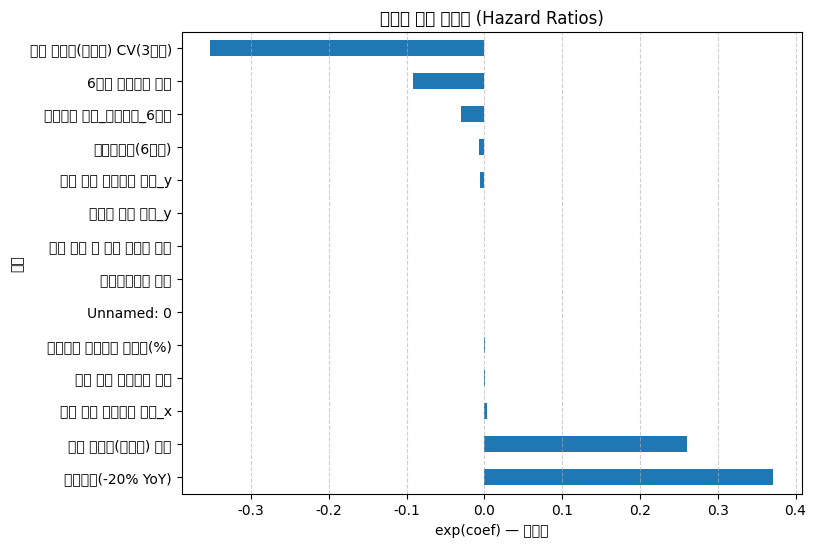

In [5]:
#시각화
import matplotlib.pyplot as plt

# 위험비 정렬
hazard_ratios = cph.params_.sort_values(ascending=False)
plt.figure(figsize=(8,6))
hazard_ratios.plot(kind='barh')
plt.title('변수별 폐업 위험비 (Hazard Ratios)')
plt.xlabel('exp(coef) — 위험비')
plt.ylabel('변수')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.show()


생존곡선 : 특정 변수 수준별 생존확률을 그림.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54224 (\N{HANGUL SYLLABLE PYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

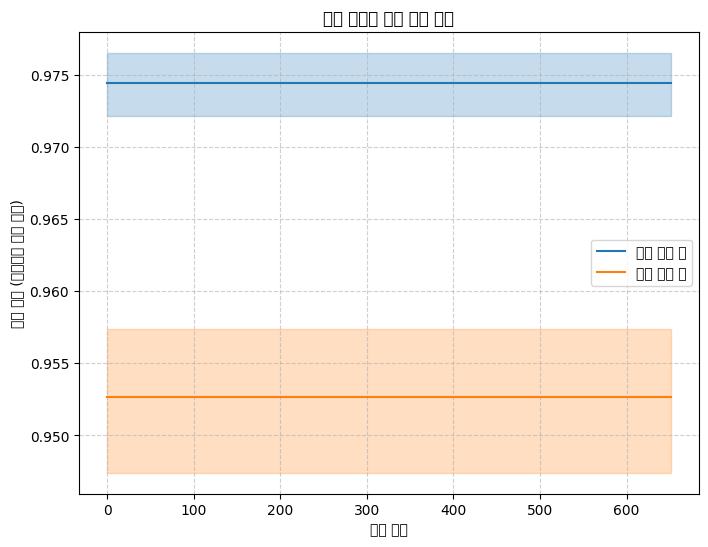

In [6]:
# 생존곡선
# 예: 급감여부에 따른 생존확률 비교
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))
for val, label in zip([0,1], ["매출 급감 無", "매출 급감 有"]):
    mask = df['급감여부(-20% YoY)'] == val
    kmf.fit(df.loc[mask, '운영개월'], df.loc[mask, 'event'], label=label)
    kmf.plot_survival_function()

plt.title("급감 여부에 따른 생존 확률")
plt.xlabel("운영 개월")
plt.ylabel("생존 확률 (폐업하지 않을 확률)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


🧭 PCA 기반 Cox PH 모델 적합 (4개 주성분 사용)
Iteration 1: norm_delta = 4.27e-01, step_size = 0.9500, log_lik = -452.54618, newton_decrement = 5.41e+00, seconds_since_start = 0.0
Iteration 2: norm_delta = 5.02e-02, step_size = 0.9500, log_lik = -447.27880, newton_decrement = 4.72e-02, seconds_since_start = 0.0
Iteration 3: norm_delta = 9.13e-03, step_size = 0.9500, log_lik = -447.22880, newton_decrement = 1.25e-03, seconds_since_start = 0.0
Iteration 4: norm_delta = 1.86e-04, step_size = 1.0000, log_lik = -447.22753, newton_decrement = 5.02e-07, seconds_since_start = 0.0
Iteration 5: norm_delta = 7.52e-08, step_size = 1.0000, log_lik = -447.22753, newton_decrement = 8.16e-14, seconds_since_start = 0.0
Convergence success after 5 iterations.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


📊 PCA 기반 CoxPH 모델 결과 요약:
               coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                  
PC1       -0.056409   0.945153  0.072262       -0.198040        0.085223   
PC2       -0.219277   0.803099  0.087287       -0.390358       -0.048197   
PC3        0.106661   1.112557  0.112248       -0.113342        0.326663   
PC4       -0.162324   0.850165  0.118736       -0.395043        0.070394   
PC5        0.143510   1.154319  0.183701       -0.216537        0.503557   

           exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                               
PC1                   0.820337             1.088960     0.0 -0.780607   
PC2                   0.676815             0.952946     0.0 -2.512129   
PC3                   0.892846             1.386335     0.0  0.950224   
PC4                   0.673651             1.072931     0.0 -1.367102   
PC5

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


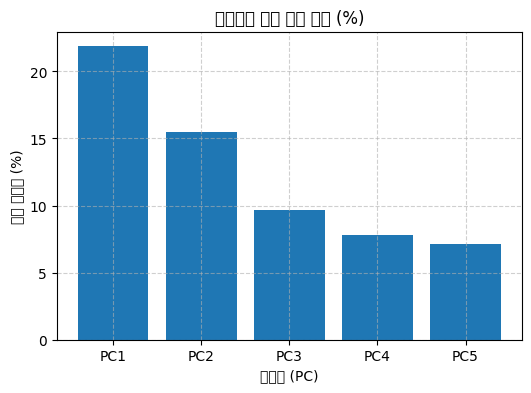

In [13]:
# === PCA(4개) + CoxPH 한 번에 실행하는 셀 ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

print("🧭 PCA 기반 Cox PH 모델 적합 (4개 주성분 사용)")

# 0) 기본 컬럼 확인/추론 -------------------------------------------------------
# 가맹점 ID 컬럼 자동 탐색
if 'store_id_col' not in locals() or store_id_col is None:
    store_id_col = None
    for col in ['가맹점구분번호', '가맹점ID', '가맹점번호', 'store_id', 'storeID']:
        if col in df.columns:
            store_id_col = col
            break
    if store_id_col is None:
        # 부분 일치로도 재탐색
        for col in df.columns:
            if '가맹점' in col and ('구분' in col or 'ID' in col or 'id' in col):
                store_id_col = col
                break
if store_id_col is None:
    raise ValueError("가맹점 ID 컬럼을 찾을 수 없습니다. (예: '가맹점구분번호')")

# 기준년월 존재/정렬 보장
if '기준년월' not in df.columns:
    raise ValueError("'기준년월' 컬럼이 필요합니다.")
if not np.issubdtype(df['기준년월'].dtype, np.datetime64):
    df['기준년월'] = pd.to_datetime(df['기준년월'], errors='coerce')
df = df.sort_values([store_id_col, '기준년월']).reset_index(drop=True)

# last_obs 없으면 생성 (store-level 마지막 관측치)
if 'last_obs' not in locals():
    last_obs = df.groupby(store_id_col).tail(1).copy()

# 운영개월/event 컬럼 확인
for col in ['운영개월', 'event']:
    if col not in last_obs.columns:
        raise ValueError(f"'{col}' 컬럼이 없습니다. 기존 셀에서 운영개월/event 생성 단계를 먼저 실행하세요.")

# 1) features 자동 정의(없거나 비어 있으면) -------------------------------------
if 'features' not in locals() or not isinstance(features, list) or len(features) == 0:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # 제외할 컬럼들(기간/이벤트/ID/확률 등)
    exclude_exact = {'운영개월', 'event'}
    exclude_contains = ['년월', 'date', '일자', 'timestamp', '위험확률']
    exclude_ids = {store_id_col}
    features_auto = []
    for c in numeric_cols:
        if c in exclude_exact or c in exclude_ids:
            continue
        if any(tok in c for tok in exclude_contains):
            continue
        features_auto.append(c)
    features = features_auto
    print(f"features 자동 생성 완료 (개수={len(features)}):", features[:10], " ...")

# 2) Cox 입력 데이터 구성 -------------------------------------------------------
cox_features = [f for f in features if f in last_obs.columns]
cox_df = last_obs[['운영개월', 'event'] + cox_features].copy()
# 결측/무한 처리
cox_df = cox_df.replace([np.inf, -np.inf], np.nan).dropna()
n_rows = cox_df.shape[0]
if n_rows < 50:
    raise ValueError(f"Cox 적합 데이터가 너무 적습니다. (rows={n_rows}) — feature/결측 기준을 완화해보세요.")

# 3) 표준화 + PCA(4개 주성분) ---------------------------------------------------
X = cox_df[cox_features].values
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X_scaled)
pca_cols = [f'PC{i+1}' for i in range(5)]
pca_df = pd.DataFrame(X_pca, columns=pca_cols, index=cox_df.index)

cox_pca_df = pd.concat([cox_df[['운영개월', 'event']], pca_df], axis=1)

# 4) Cox PH 적합 ----------------------------------------------------------------
cph_pca = CoxPHFitter()
cph_pca.fit(cox_pca_df, duration_col='운영개월', event_col='event', show_progress=True)

print("\n📊 PCA 기반 CoxPH 모델 결과 요약:")
print(cph_pca.summary)

# Concordance Index
c_index = concordance_index(
    cox_pca_df['운영개월'],
    -cph_pca.predict_partial_hazard(cox_pca_df),
    cox_pca_df['event']
)
print(f"\nC-index (예측 정확도): {c_index:.4f}")

# 5) 주성분 설명 분산 비율 ------------------------------------------------------
print("\n🔎 주성분별 설명 분산 비율:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var*100:.2f}%")

# 6) 시각화 ---------------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.bar(pca_cols, pca.explained_variance_ratio_ * 100)
plt.title("주성분별 설명 분산 비율 (%)")
plt.ylabel("분산 설명력 (%)")
plt.xlabel("주성분 (PC)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [15]:
# --- 주성분 로딩(loading) 행렬 보기 ---
loading_matrix = pd.DataFrame(
    pca.components_.T,
    index=cox_features,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print("🔍 주성분 로딩(Loading) 행렬 (상위 기여 변수 표시):")
display(loading_matrix.round(3))

# 각 주성분별로 절댓값 기준 상위 기여 변수 보기
for i in range(5):
    print(f"\n📘 PC{i+1} 주요 기여 변수 Top 5")
    top_vars = loading_matrix.iloc[:, i].abs().sort_values(ascending=False).head(5).index
    print(top_vars.tolist())


🔍 주성분 로딩(Loading) 행렬 (상위 기여 변수 표시):


,PC1,PC2,PC3,PC4,PC5
Unnamed: 0,-0.054,0.077,-0.105,0.663,0.110
배달매출금액 비율,0.077,-0.230,0.075,-0.493,0.142
동일 업종 매출금액 비율_x,0.441,-0.158,0.365,0.083,0.003
동일 업종 매출건수 비율,0.368,-0.196,0.322,0.079,-0.011
동일 상권 내 해지 가맹점 비중,0.090,0.066,0.107,0.489,0.151
전월대비 매출금액 감소율(%),-0.067,0.371,0.344,-0.139,0.062
6개월 하락추세 여부,-0.182,-0.440,0.070,0.011,-0.017
매출금액 구간_회복지수_6개월,0.208,0.534,0.004,-0.092,0.055
급감여부(-20% YoY),-0.174,-0.400,0.135,0.161,0.224
매출 안정성(변동성) CV(3개월),-0.381,0.115,0.533,0.002,0.047



📘 PC1 주요 기여 변수 Top 5
['동일 업종 매출금액 비율_y', '동일 업종 매출금액 비율_x', '매출 안정성(변동성) 여부', '매출 안정성(변동성) CV(3개월)', '동일 업종 매출건수 비율']

📘 PC2 주요 기여 변수 Top 5
['매출금액 구간_회복지수_6개월', '6개월 하락추세 여부', '급감여부(-20% YoY)', '전월대비 매출금액 감소율(%)', '매출탄력도(6개월)']

📘 PC3 주요 기여 변수 Top 5
['매출 안정성(변동성) CV(3개월)', '매출 안정성(변동성) 여부', '동일 업종 매출금액 비율_x', '전월대비 매출금액 감소율(%)', '동일 업종 매출금액 비율_y']

📘 PC4 주요 기여 변수 Top 5
['Unnamed: 0', '배달매출금액 비율', '동일 상권 내 해지 가맹점 비중', '급감여부(-20% YoY)', '전월대비 매출금액 감소율(%)']

📘 PC5 주요 기여 변수 Top 5
['재방문 고객 비중_y', '매출탄력도(6개월)', '급감여부(-20% YoY)', '동일 상권 내 해지 가맹점 비중', '배달매출금액 비율']


🧲 Ridge 기반 변수선택 → Cox PH 적합
선택된 변수(14개): ['동일 업종 매출금액 비율_y', '동일 업종 매출금액 비율_x', '배달매출금액 비율', '급감여부(-20% YoY)', '매출 안정성(변동성) 여부', '동일 상권 내 해지 가맹점 비중', '동일 업종 매출건수 비율', '매출 안정성(변동성) CV(3개월)', '6개월 하락추세 여부', '매출탄력도(6개월)', '전월대비 매출금액 감소율(%)', '재방문 고객 비중_y', 'Unnamed: 0', '매출금액 구간_회복지수_6개월']
Iteration 1: norm_delta = 1.01e+00, step_size = 0.9500, log_lik = -452.54618, newton_decrement = 1.47e+01, seconds_since_start = 0.0
Iteration 2: norm_delta = 1.10e-01, step_size = 0.9500, log_lik = -439.69917, newton_decrement = 7.92e-01, seconds_since_start = 0.0
Iteration 3: norm_delta = 3.32e-02, step_size = 0.9500, log_lik = -438.85415, newton_decrement = 3.26e-02, seconds_since_start = 0.0
Iteration 4: norm_delta = 2.72e-03, step_size = 1.0000, log_lik = -438.82041, newton_decrement = 1.15e-04, seconds_since_start = 0.0
Iteration 5: norm_delta = 1.12e-05, step_size = 1.0000, log_lik = -438.82029, newton_decrement = 1.86e-09, seconds_since_start = 0.0
Convergence success after 5 iterations.



📊 Ridge 선택 변수 기반 CoxPH 요약
                             coef  exp(coef)      se(coef)  coef lower 95%  \
covariate                                                                    
동일 업종 매출금액 비율_y     -7.103715e-03   0.992921  2.756835e-03   -1.250701e-02   
동일 업종 매출금액 비율_x      4.618595e-03   1.004629  1.721770e-03    1.243988e-03   
배달매출금액 비율            6.904494e-07   1.000001  2.664741e-07    1.681698e-07   
급감여부(-20% YoY)       4.113854e-01   1.508907  3.191645e-01   -2.141654e-01   
매출 안정성(변동성) 여부       4.470933e-01   1.563760  4.975740e-01   -5.281337e-01   
동일 상권 내 해지 가맹점 비중   -4.525968e-07   1.000000  2.759076e-07   -9.933656e-07   
동일 업종 매출건수 비율        9.548652e-04   1.000955  8.737502e-04   -7.576538e-04   
매출 안정성(변동성) CV(3개월) -5.665744e-01   0.567466  8.451680e-01   -2.223073e+00   
6개월 하락추세 여부         -1.990372e-01   0.819519  3.275941e-01   -8.411098e-01   
매출탄력도(6개월)          -6.169985e-03   0.993849  1.681320e-02   -3.912326e-02   
전월대비 매출금액 감소율(%)     5.684394e-04   1

/tmp/ipython-input-2347396856.py:115: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2347396856.py:115: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2347396856.py:115: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2347396856.py:115: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2347396856.py:115: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2347396856.py:115: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2347396856.py:115: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_l

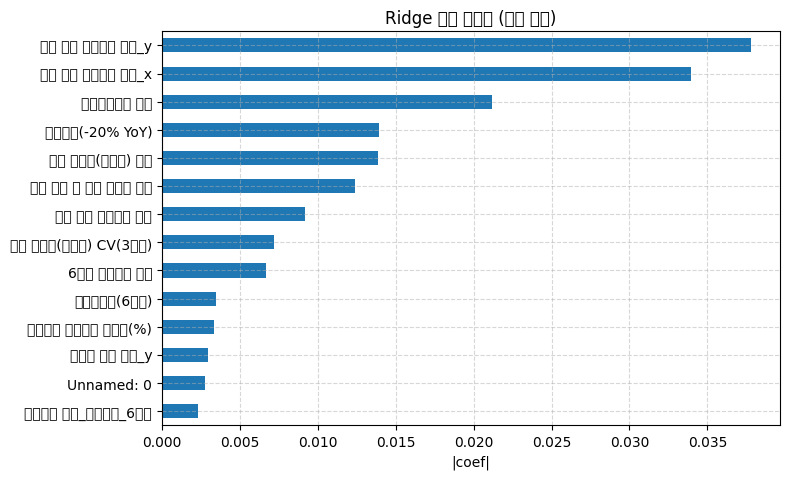

In [16]:
# === Ridge 변수선택 → Cox PH 모델 ===
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifierCV
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
import matplotlib.pyplot as plt

print("🧲 Ridge 기반 변수선택 → Cox PH 적합")

# 0) 기본 컬럼/데이터 준비 -------------------------------------------------------
# 가맹점 ID 자동 탐색
if 'store_id_col' not in locals() or store_id_col is None:
    store_id_col = None
    for col in ['가맹점구분번호','가맹점ID','가맹점번호','store_id','storeID']:
        if col in df.columns:
            store_id_col = col; break
    if store_id_col is None:
        for col in df.columns:
            if '가맹점' in col and ('구분' in col or 'ID' in col or 'id' in col):
                store_id_col = col; break
if store_id_col is None:
    raise ValueError("가맹점 ID 컬럼을 찾을 수 없습니다.")

# 기준년월 정렬
if '기준년월' not in df.columns:
    raise ValueError("'기준년월' 컬럼이 필요합니다.")
if not np.issubdtype(df['기준년월'].dtype, np.datetime64):
    df['기준년월'] = pd.to_datetime(df['기준년월'], errors='coerce')
df = df.sort_values([store_id_col, '기준년월']).reset_index(drop=True)

# last_obs 없으면 생성 (store-level 마지막 관측치)
if 'last_obs' not in locals():
    last_obs = df.groupby(store_id_col).tail(1).copy()

# 운영개월/event 확인
for col in ['운영개월', 'event']:
    if col not in last_obs.columns:
        raise ValueError(f"'{col}' 컬럼이 없습니다. (운영개월/event 생성 셀 먼저 실행하세요)")

# 1) 후보 피처 구성 (features 없으면 자동 생성) ----------------------------------
if 'features' not in locals() or not isinstance(features, list) or len(features)==0:
    numeric_cols = last_obs.select_dtypes(include=[np.number]).columns.tolist()
    exclude_exact = {'운영개월','event'}
    exclude_contains = ['년월','date','일자','timestamp','위험확률']
    exclude_ids = {store_id_col}
    features = []
    for c in numeric_cols:
        if c in exclude_exact or c in exclude_ids:
            continue
        if any(tok in c for tok in exclude_contains):
            continue
        features.append(c)

if len(features) < 2:
    raise ValueError(f"사용 가능한 수치 피처가 부족합니다. (features={features})")

# 결측/무한 처리
use_df = last_obs.copy().replace([np.inf,-np.inf], np.nan)
use_df = use_df.dropna(subset=['event'] + features)

# event가 단일 클래스면 Ridge 불가 → 예외
if use_df['event'].nunique() < 2:
    raise ValueError("event가 단일 클래스입니다. Ridge 분류를 할 수 없습니다. (폐업/미폐업이 모두 필요)")

X_all = use_df[features].values
y_all = use_df['event'].astype(int).values

# 2) 스케일링 + Ridge 분류로 변수 중요도(계수 절댓값) 산출 ------------------------
scaler = StandardScaler()
X_all_s = scaler.fit_transform(X_all)

# 여러 알파를 CV로 탐색 (로지스틱 대신 RidgeClassifierCV 사용: L2 정규화)
alphas = np.logspace(-3, 3, 13)
ridge = RidgeClassifierCV(alphas=alphas, cv=5)
ridge.fit(X_all_s, y_all)

coefs = ridge.coef_.ravel()  # shape: (n_features,)
coef_abs = np.abs(coefs)
importance = pd.Series(coef_abs, index=features).sort_values(ascending=False)

# 3) 상위 변수 선택 전략 ----------------------------------------------------------
# - top_k 개수 또는 누적 비중 기준 중 택1
top_k = 15  # 필요 시 조정
selected_features = importance.head(top_k).index.tolist()

print(f"선택된 변수({len(selected_features)}개):", selected_features)

# 4) Cox PH 적합 (선택 변수만 사용) ----------------------------------------------
cox_df = use_df[['운영개월','event'] + selected_features].dropna().copy()
if cox_df.shape[0] < 50:
    raise ValueError(f"Cox 적합 데이터가 부족합니다. rows={cox_df.shape[0]}")

cph_sel = CoxPHFitter()
cph_sel.fit(cox_df, duration_col='운영개월', event_col='event', show_progress=True)

print("\n📊 Ridge 선택 변수 기반 CoxPH 요약")
print(cph_sel.summary)

# Concordance Index
c_index = concordance_index(
    cox_df['운영개월'],
    -cph_sel.predict_partial_hazard(cox_df),
    cox_df['event']
)
print(f"\nC-index: {c_index:.4f}")

# 5) (선택) Ridge 계수 시각화 -----------------------------------------------------
plt.figure(figsize=(8, max(3, 0.35*len(selected_features))))
importance.loc[selected_features].sort_values().plot(kind='barh')
plt.title("Ridge 계수 절댓값 (선택 변수)")
plt.xlabel("|coef|")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


🧲 Lasso(L1) 기반 변수선택 → Cox PH 적합


/tmp/ipython-input-693150705.py:128: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-693150705.py:128: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-693150705.py:128: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-693150705.py:128: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-693150705.py:128: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-693150705.py:128: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-693150705.py:128: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

선택된 변수(14개): ['Unnamed: 0', '배달매출금액 비율', '동일 업종 매출금액 비율_x', '동일 업종 매출건수 비율', '동일 상권 내 해지 가맹점 비중', '전월대비 매출금액 감소율(%)', '6개월 하락추세 여부', '매출금액 구간_회복지수_6개월', '급감여부(-20% YoY)', '매출 안정성(변동성) CV(3개월)', '매출탄력도(6개월)', '매출 안정성(변동성) 여부', '동일 업종 매출금액 비율_y', '재방문 고객 비중_y']
Iteration 1: norm_delta = 1.01e+00, step_size = 0.9500, log_lik = -452.54618, newton_decrement = 1.47e+01, seconds_since_start = 0.0
Iteration 2: norm_delta = 1.10e-01, step_size = 0.9500, log_lik = -439.69917, newton_decrement = 7.92e-01, seconds_since_start = 0.0
Iteration 3: norm_delta = 3.32e-02, step_size = 0.9500, log_lik = -438.85415, newton_decrement = 3.26e-02, seconds_since_start = 0.0
Iteration 4: norm_delta = 2.72e-03, step_size = 1.0000, log_lik = -438.82041, newton_decrement = 1.15e-04, seconds_since_start = 0.0
Iteration 5: norm_delta = 1.12e-05, step_size = 1.0000, log_lik = -438.82029, newton_decrement = 1.86e-09, seconds_since_start = 0.0
Convergence success after 5 iterations.

📊 Lasso 선택 변수 기반 CoxPH 요약
        

/tmp/ipython-input-693150705.py:128: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-693150705.py:128: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-693150705.py:128: UserWarning: Glyph 53469 (\N{HANGUL SYLLABLE TAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.

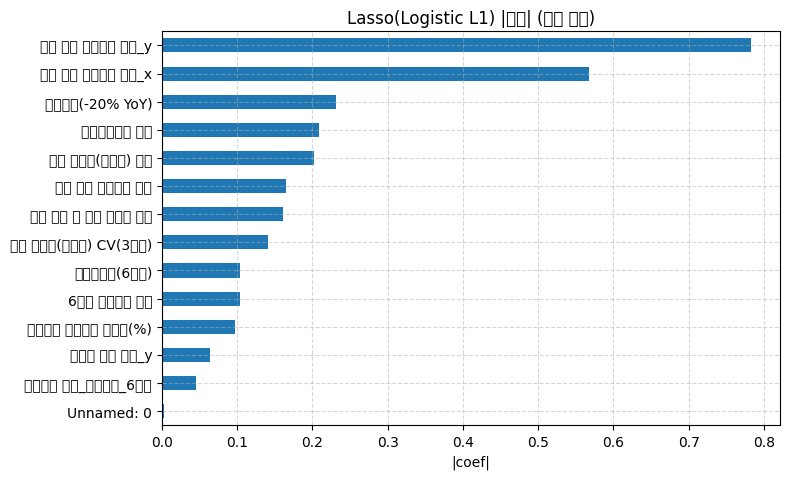

In [17]:
# === Lasso(로지스틱 L1) 변수선택 → Cox PH 모델 ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

print("🧲 Lasso(L1) 기반 변수선택 → Cox PH 적합")

# 0) 기본 컬럼/데이터 준비 -------------------------------------------------------
# 가맹점 ID 자동 탐색
if 'store_id_col' not in locals() or store_id_col is None:
    store_id_col = None
    for col in ['가맹점구분번호','가맹점ID','가맹점번호','store_id','storeID']:
        if col in df.columns:
            store_id_col = col; break
    if store_id_col is None:
        for col in df.columns:
            if '가맹점' in col and ('구분' in col or 'ID' in col or 'id' in col):
                store_id_col = col; break
if store_id_col is None:
    raise ValueError("가맹점 ID 컬럼을 찾을 수 없습니다.")

# 기준년월 정렬
if '기준년월' not in df.columns:
    raise ValueError("'기준년월' 컬럼이 필요합니다.")
if not np.issubdtype(df['기준년월'].dtype, np.datetime64):
    df['기준년월'] = pd.to_datetime(df['기준년월'], errors='coerce')
df = df.sort_values([store_id_col, '기준년월']).reset_index(drop=True)

# last_obs 없으면 생성 (store-level 마지막 관측치)
if 'last_obs' not in locals():
    last_obs = df.groupby(store_id_col).tail(1).copy()

# 운영개월/event 확인
for col in ['운영개월', 'event']:
    if col not in last_obs.columns:
        raise ValueError(f"'{col}' 컬럼이 없습니다. (운영개월/event 생성 셀 먼저 실행하세요)")

# 1) 후보 피처 구성 (features 없으면 자동 생성) ----------------------------------
if 'features' not in locals() or not isinstance(features, list) or len(features)==0:
    numeric_cols = last_obs.select_dtypes(include=[np.number]).columns.tolist()
    exclude_exact = {'운영개월','event'}
    exclude_contains = ['년월','date','일자','timestamp','위험확률']
    exclude_ids = {store_id_col}
    features = []
    for c in numeric_cols:
        if c in exclude_exact or c in exclude_ids:
            continue
        if any(tok in c for tok in exclude_contains):
            continue
        features.append(c)

if len(features) < 2:
    raise ValueError(f"사용 가능한 수치 피처가 부족합니다. (features={features})")

# 결측/무한 처리
use_df = last_obs.copy().replace([np.inf,-np.inf], np.nan)
use_df = use_df.dropna(subset=['event'] + features)

# event가 단일 클래스면 Lasso 불가 → 예외
if use_df['event'].nunique() < 2:
    raise ValueError("event가 단일 클래스입니다. L1 로지스틱 분류를 할 수 없습니다. (폐업/미폐업이 모두 필요)")

X_all = use_df[features].values
y_all = use_df['event'].astype(int).values

# 2) 스케일링 + L1(라쏘) 로지스틱으로 변수선택 -----------------------------------
scaler = StandardScaler()
X_all_s = scaler.fit_transform(X_all)

# LogisticRegressionCV with L1 (C-search via CV)
# liblinear: L1 지원, 데이터가 크면 saga로 변경 가능
lasso_cv = LogisticRegressionCV(
    Cs=np.logspace(-3, 3, 13),
    cv=5,
    penalty='l1',
    solver='liblinear',      # 대규모면 'saga' 고려
    class_weight='balanced', # 불균형 완화
    scoring='roc_auc',
    max_iter=2000,
    n_jobs=-1,
    refit=True
)
lasso_cv.fit(X_all_s, y_all)

coefs = lasso_cv.coef_.ravel()            # shape: (n_features,)
coef_abs = np.abs(coefs)
non_zero_mask = coef_abs > 1e-8           # 선택 기준
selected_features = np.array(features)[non_zero_mask].tolist()

# 만약 모든 계수가 0이면(강한 정규화), 가장 큰 절댓값 상위 K로 백업
if len(selected_features) == 0:
    print("⚠️ 모든 계수가 0 → 상위 |coef| 기준 백업 선택 수행")
    top_k = min(12, len(features))
    selected_features = pd.Series(coef_abs, index=features).sort_values(ascending=False).head(top_k).index.tolist()

print(f"선택된 변수({len(selected_features)}개):", selected_features)

# 3) Cox PH 적합 (선택 변수만 사용) ----------------------------------------------
cox_df = use_df[['운영개월','event'] + selected_features].dropna().copy()
if cox_df.shape[0] < 50:
    raise ValueError(f"Cox 적합 데이터가 부족합니다. rows={cox_df.shape[0]}")

cph_sel = CoxPHFitter()
cph_sel.fit(cox_df, duration_col='운영개월', event_col='event', show_progress=True)

print("\n📊 Lasso 선택 변수 기반 CoxPH 요약")
print(cph_sel.summary)

# Concordance Index
c_index = concordance_index(
    cox_df['운영개월'],
    -cph_sel.predict_partial_hazard(cox_df),
    cox_df['event']
)
print(f"\nC-index: {c_index:.4f}")

# 4) (선택) Lasso 계수 시각화 -----------------------------------------------------
coef_series = pd.Series(coef_abs, index=features)
plt.figure(figsize=(8, max(3, 0.35*len(selected_features))))
coef_series.loc[selected_features].sort_values().plot(kind='barh')
plt.title("Lasso(Logistic L1) |계수| (선택 변수)")
plt.xlabel("|coef|")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
